In [ ]:
import os
import gc
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import umap

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

Load Dataset

In [ ]:
path = kagglehub.dataset_download("aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented")
base_dir = os.path.join(path, 'combined_images')

CLASS_MAP = {"Mild": "MildDemented", "Moderate": "ModerateDemented", "Non": "NonDemented", "VeryMild": "VeryMildDemented"}
SAMPLES_PER_CLASS = 1500

all_img_paths, all_labels = [], []
for label, folder in CLASS_MAP.items():
    folder_path = os.path.join(base_dir, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[:SAMPLES_PER_CLASS]
    for fname in files:
        all_img_paths.append(os.path.join(folder_path, fname))
        all_labels.append(label)

100%|██████████| 398M/398M [00:03<00:00, 131MB/s]

Extracting files...


EDA

In [ ]:
meta_data = []

paths_by_class = {}
for path, label in zip(all_img_paths, all_labels):
    if label not in paths_by_class:
        paths_by_class[label] = []
    paths_by_class[label].append(path)

for label, paths in paths_by_class.items():
    sampled_paths = paths[:SAMPLES_PER_CLASS]

    for img_path in sampled_paths:
        img = cv2.imread(img_path)
        if img is not None:
            height, width, _ = img.shape
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            mean_intensity = np.mean(gray_img)
            std_intensity  = np.std(gray_img)
            aspect_ratio   = width / height

            meta_data.append({
                'Kategori': label,
                'Width': width,
                'Height': height,
                'Mean_Intensity': mean_intensity,
                'Std_Intensity': std_intensity,
                'Aspect_Ratio': aspect_ratio
            })

df_meta = pd.DataFrame(meta_data)
print("\n--- Verifikasi Jumlah Data di df_meta ---")
print(df_meta['Kategori'].value_counts())


--- Verifikasi Jumlah Data di df_meta ---
Kategori
Mild        1500
Moderate    1500
Non         1500
VeryMild    1500
Name: count, dtype: int64


In [ ]:
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(all_labels)
class_names   = list(label_encoder.classes_)
n_classes     = len(class_names)

data_info = {label: all_labels.count(label) for label in class_names}
df_dist   = pd.DataFrame(list(data_info.items()), columns=['Kategori', 'Jumlah'])

if 'class_names' not in locals() and 'df_meta' in locals():
    class_names = sorted(df_meta['Kategori'].unique().tolist())

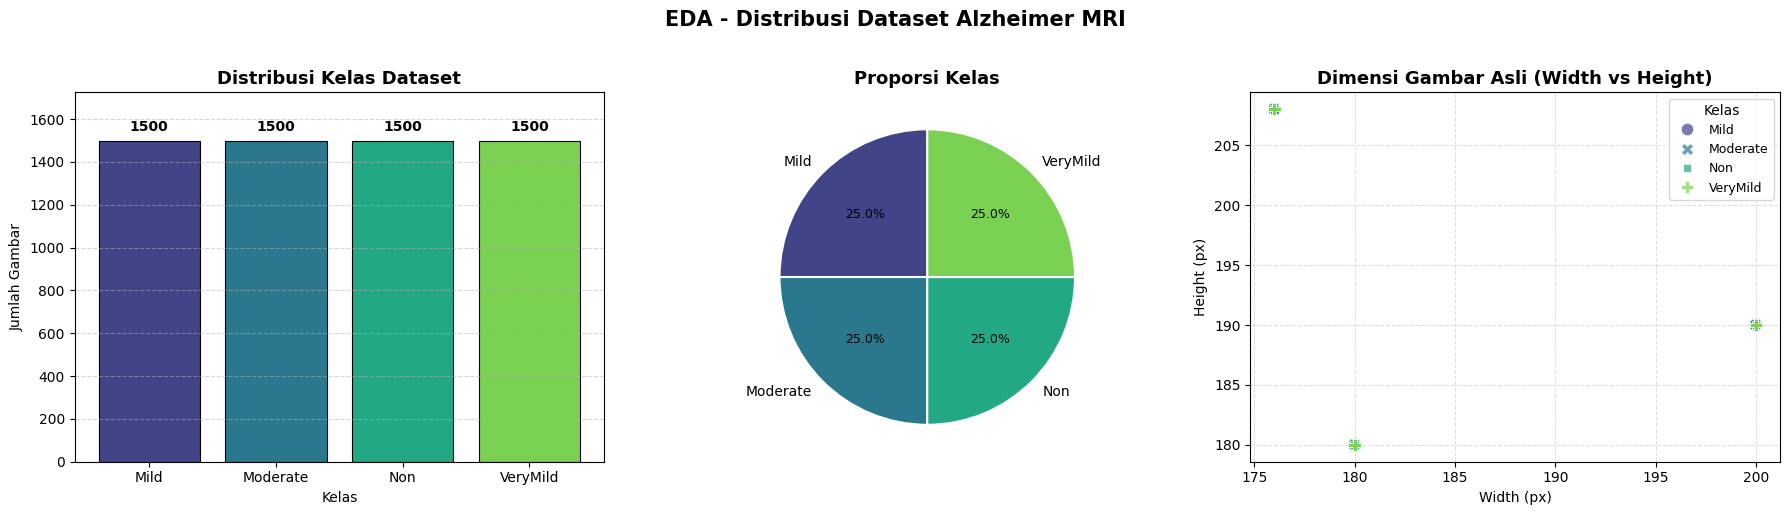

In [ ]:
# DISTRIBUSI & PROPORSI DATASET

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
colors = sns.color_palette('viridis', n_classes)

ax = axes1[0]
bars = ax.bar(df_dist['Kategori'], df_dist['Jumlah'], color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, df_dist['Jumlah']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Distribusi Kelas Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Gambar')
ax.set_xlabel('Kelas')
ax.set_ylim(0, df_dist['Jumlah'].max() * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax = axes1[1]
wedges, texts, autotexts = ax.pie(
    df_dist['Jumlah'], labels=df_dist['Kategori'],
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title('Proporsi Kelas', fontsize=13, fontweight='bold')

ax = axes1[2]
sns.scatterplot(data=df_meta, x='Width', y='Height', hue='Kategori', style='Kategori',
                palette='viridis', s=80, alpha=0.7, ax=ax)
ax.set_title('Dimensi Gambar Asli (Width vs Height)', fontsize=13, fontweight='bold')
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
ax.legend(title='Kelas', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('EDA - Distribusi Dataset Alzheimer MRI', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

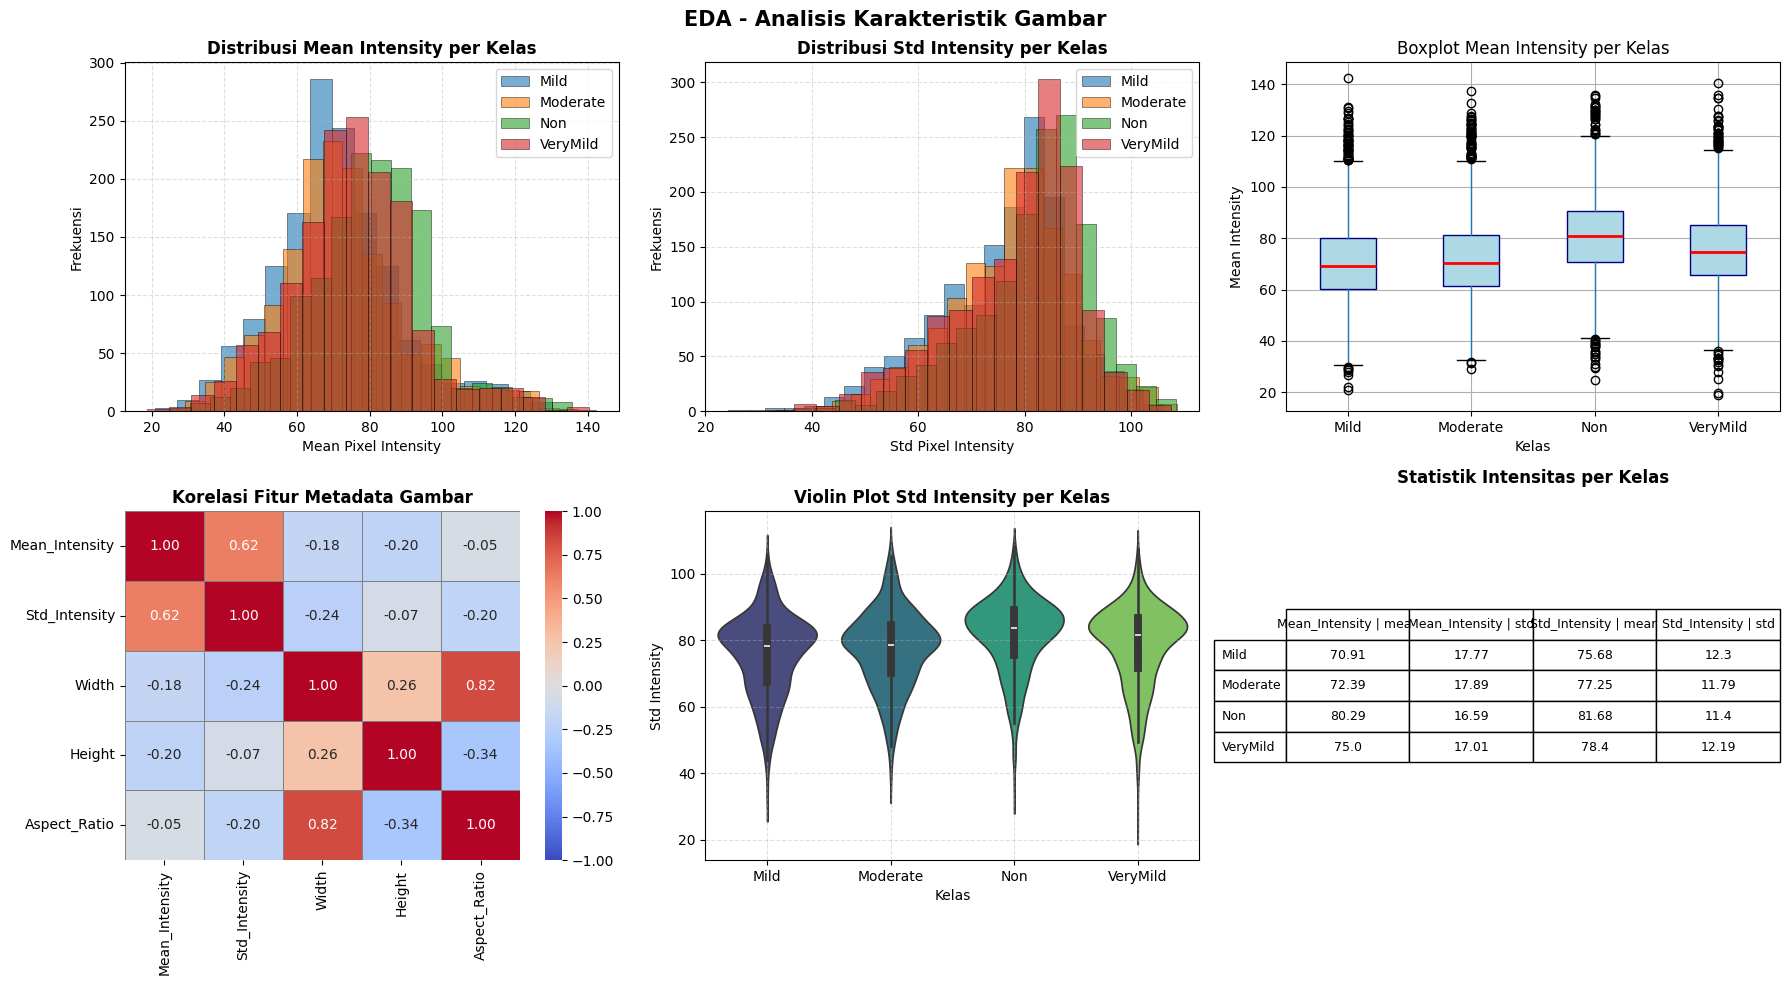

In [ ]:
# ANALISIS KARAKTERISTIK GAMBAR

fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))

ax = axes2[0, 0]
for label in class_names:
    subset = df_meta[df_meta['Kategori'] == label]
    ax.hist(subset['Mean_Intensity'], bins=20, label=label, alpha=0.6, edgecolor='black', linewidth=0.5)
ax.set_title('Distribusi Mean Intensity per Kelas', fontweight='bold')
ax.set_xlabel('Mean Pixel Intensity')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes2[0, 1]
for label in class_names:
    subset = df_meta[df_meta['Kategori'] == label]
    ax.hist(subset['Std_Intensity'], bins=20, label=label, alpha=0.6, edgecolor='black', linewidth=0.5)
ax.set_title('Distribusi Std Intensity per Kelas', fontweight='bold')
ax.set_xlabel('Std Pixel Intensity')
ax.set_ylabel('Frekuensi')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes2[0, 2]
df_meta.boxplot(column='Mean_Intensity', by='Kategori', ax=ax, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('Boxplot Mean Intensity per Kelas', fontweight='bold')
ax.set_xlabel('Kelas')
ax.set_ylabel('Mean Intensity')
plt.sca(ax)
plt.title('Boxplot Mean Intensity per Kelas')

ax = axes2[1, 0]
pivot_corr = df_meta[['Mean_Intensity', 'Std_Intensity', 'Width', 'Height', 'Aspect_Ratio']].corr()
sns.heatmap(pivot_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, linecolor='gray', vmin=-1, vmax=1)
ax.set_title('Korelasi Fitur Metadata Gambar', fontweight='bold')

ax = axes2[1, 1]
sns.violinplot(data=df_meta, x='Kategori', y='Std_Intensity', palette='viridis', ax=ax)
ax.set_title('Violin Plot Std Intensity per Kelas', fontweight='bold')
ax.set_xlabel('Kelas')
ax.set_ylabel('Std Intensity')
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes2[1, 2]
print_df = df_meta.groupby('Kategori')[['Mean_Intensity', 'Std_Intensity', 'Width', 'Height']].describe().T
ax.axis('off')

tbl_data = df_meta.groupby('Kategori')[['Mean_Intensity', 'Std_Intensity']].agg(['mean', 'std']).round(2)
tbl = ax.table(cellText=tbl_data.values,
               rowLabels=tbl_data.index,
               colLabels=[' | '.join(c) for c in tbl_data.columns],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
ax.set_title('Statistik Intensitas per Kelas', fontweight='bold', pad=20)

plt.suptitle('EDA - Analisis Karakteristik Gambar', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

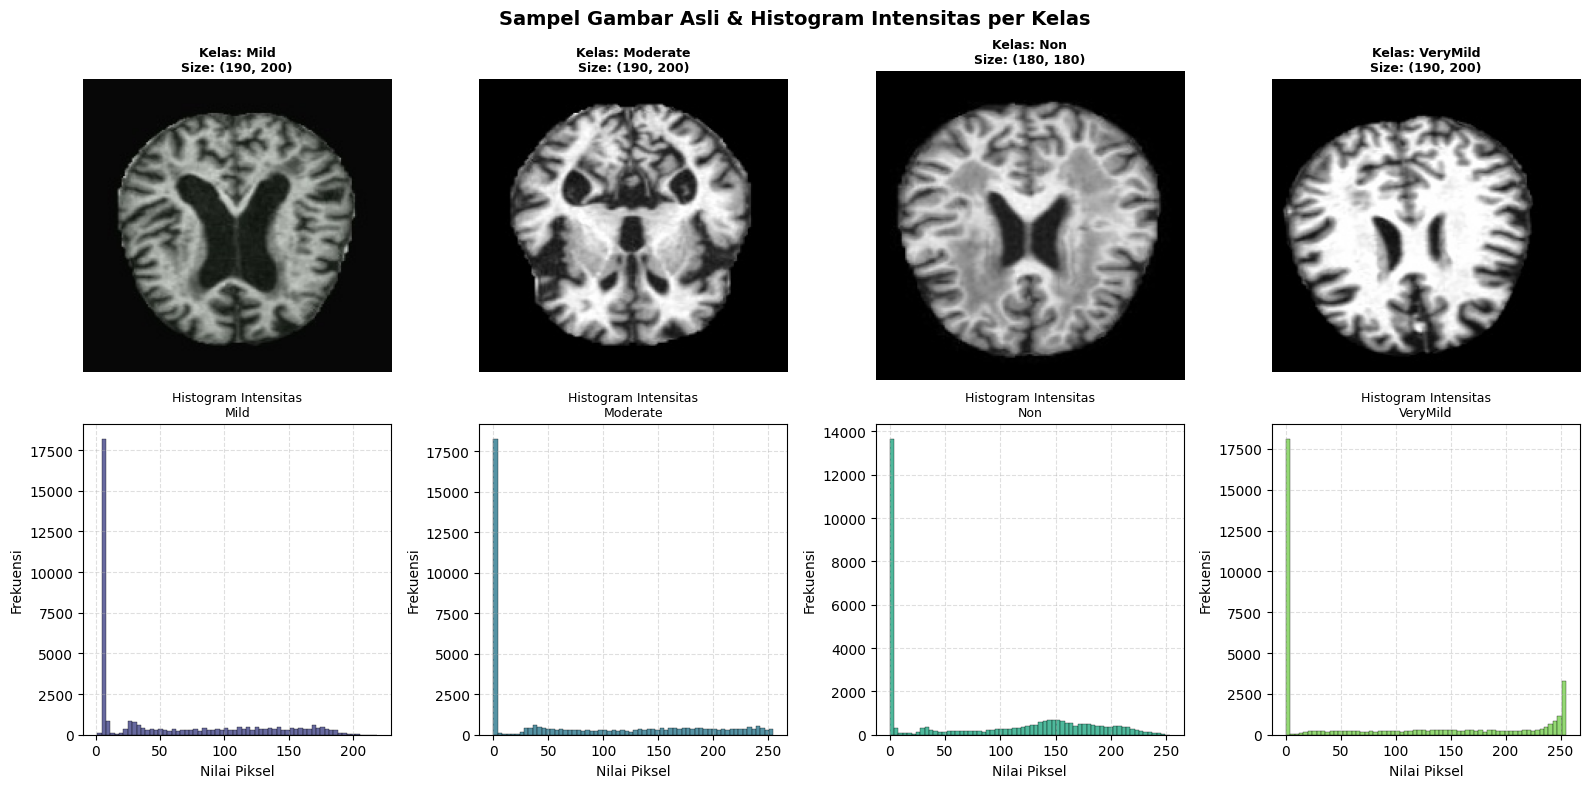

In [ ]:
# SAMPEL GAMBAR & HISTOGRAM INTENSITAS

class_paths = {label: os.path.join(base_dir, folder) for label, folder in CLASS_MAP.items()}
class_names = sorted(list(class_paths.keys()))
n_classes   = len(class_names)

fig3, axes3 = plt.subplots(2, 4, figsize=(16, 8))
colors_hist = sns.color_palette('viridis', n_classes)

for idx, label in enumerate(class_names):
    path  = class_paths[label]
    files = sorted([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    img_bgr  = cv2.imread(os.path.join(path, files[0]))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    ax_img = axes3[0, idx]
    ax_img.imshow(img_rgb)
    ax_img.set_title(f'Kelas: {label}\nSize: {img_rgb.shape[:2]}', fontsize=9, fontweight='bold')
    ax_img.axis('off')

    ax_hist = axes3[1, idx]
    ax_hist.hist(img_gray.ravel(), bins=64, color=colors_hist[idx],
                 edgecolor='black', linewidth=0.3, alpha=0.8)
    ax_hist.set_title(f'Histogram Intensitas\n{label}', fontsize=9)
    ax_hist.set_xlabel('Nilai Piksel')
    ax_hist.set_ylabel('Frekuensi')
    ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Sampel Gambar Asli & Histogram Intensitas per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Preprocessing

In [ ]:
def preprocess_for_traditional(img_path, target_size=(128, 128)):
    gray_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if gray_img is None:
        return None

    resized_img = cv2.resize(gray_img, target_size)
    return resized_img

In [ ]:
def preprocess_for_deep(img_path, target_size=(224, 224)):
    bgr_img = cv2.imread(img_path)

    if bgr_img is None:
        return None

    rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(rgb_img, target_size)
    normalized_img = resized_img / 255.0
    return normalized_img

split data

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(all_labels)
class_names = list(le.classes_)

In [ ]:
# Split pertama: Pisahkan Train (70%) dan Sisa (30%)
X_train_paths, X_remain_paths, y_train, y_remain = train_test_split(
    all_img_paths, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

# Split kedua: Pisahkan Sisa menjadi Val (15%) dan Test (15%) -> 0.5 dari 30% adalah 15%
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_remain_paths, y_remain, test_size=0.50, stratify=y_remain, random_state=42
)

print(f"Data Train   : {len(X_train_paths)} gambar")
print(f"Data Val     : {len(X_val_paths)} gambar")
print(f"Data Test    : {len(X_test_paths)} gambar\n")

Data Train   : 4200 gambar
Data Val     : 900 gambar
Data Test    : 900 gambar



Augmentasi

In [ ]:
# Konfigurasi augmentasi menggunakan ImageDataGenerator Keras
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='reflect'
)

In [ ]:
def apply_augmentation(img_paths, target_size, num_augmentations_per_image=1):
    """Membaca gambar asli dan mengaplikasikan augmentasi secara acak.
       Generates 'num_augmentations_per_image' augmented versions for each input image."""
    augmented_images = []
    for p in img_paths:
        img = cv2.imread(p)
        img = cv2.resize(img, target_size)
        # Tambahkan dimensi batch karena datagen membutuhkan input 4D (1, H, W, C)
        img_4d = np.expand_dims(img, axis=0)

        # Generate multiple augmented versions for each image
        for _ in range(num_augmentations_per_image):
            aug_iter = train_datagen.flow(img_4d, batch_size=1)
            aug_img = next(aug_iter)[0].astype(np.uint8)
            augmented_images.append(aug_img)
    return augmented_images

Ekstraksi fitur

hog+lbp+glcm

In [ ]:
def extract_traditional_features(img_paths, is_train=False, num_augmentations_per_image_train=1):
    features = []
    printed_component_shapes = False # Flag to print shapes only once

    # 1. Penyiapan/Pool Gambar (Termasuk Augmentasi jika Data Train)
    print(f"Mempersiapkan data gambar (Augmentasi={is_train})...")
    if is_train:
        images_pool = apply_augmentation(img_paths, target_size=(128, 128), num_augmentations_per_image=num_augmentations_per_image_train)
    else:
        images_pool = [cv2.resize(cv2.imread(p), (128, 128)) for p in img_paths]

    total_images = len(images_pool)
    print(f"Mulai ekstraksi fitur tradisional untuk {total_images} citra...")

    # 2. Proses Ekstraksi Fitur per Citra
    for idx, img in enumerate(images_pool):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # A. GLCM (Tekstur)
        glcm = graycomatrix(gray, distances=[1, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=256, symmetric=True, normed=True)
        glcm_feats = [graycoprops(glcm, prop).ravel() for prop in ['contrast', 'correlation', 'energy', 'homogeneity']]
        glcm_vector = np.hstack(glcm_feats)

        # B. LBP (Tekstur Lokal)
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)

        # C. HOG (Bentuk & Orientasi Gradien)
        hog_feats = hog(gray, orientations=9, pixels_per_cell=(16, 16),
                        cells_per_block=(2, 2), visualize=False)

        # Print component shapes only once after the first image is processed
        if not printed_component_shapes:
            print("\nJumlah fitur komponen yang diekstraksi per citra:")
            print("  GLCM:", glcm_vector.shape)
            print("  LBP:", lbp_hist.shape)
            print("  HOG:", hog_feats.shape)
            printed_component_shapes = True

        # Gabungkan semua fitur tradisional
        combined_trad = np.concatenate([glcm_vector, lbp_hist, hog_feats])
        features.append(combined_trad)

        # Cetak Progress tiap kelipatan 500 citra
        processed_count = idx + 1
        if processed_count % 500 == 0 or processed_count == total_images:
            print(f" Progress: {processed_count}/{total_images} citra tradisional selesai diekstraksi.")

    return np.array(features)

# --- Cara Pemanggilan Kode ---
# Define num_aug for deep learning and traditional features consistently
num_aug = 3 # This value should be consistent with the deep learning extraction if desired

print("=== EKSTRAKSI JALUR TRADISIONAL ===")
X_train_trad = extract_traditional_features(X_train_paths, is_train=True, num_augmentations_per_image_train=num_aug)
X_val_trad   = extract_traditional_features(X_val_paths, is_train=False)
X_test_trad  = extract_traditional_features(X_test_paths, is_train=False)


print("\n--- Hasil Ekstraksi Traditional ---")
print(f"Train Shape : {X_train_trad.shape}")
print(f"Val Shape   : {X_val_trad.shape}")
print(f"Test Shape  : {X_test_trad.shape}")

=== EKSTRAKSI JALUR TRADISIONAL ===
Mempersiapkan data gambar (Augmentasi=True)...
Mulai ekstraksi fitur tradisional untuk 12600 citra...

Jumlah fitur komponen yang diekstraksi per citra:
  GLCM: (32,)
  LBP: (10,)
  HOG: (1764,)
 Progress: 500/12600 citra tradisional selesai diekstraksi.
 Progress: 1000/12600 citra tradisional selesai diekstraksi.
 Progress: 1500/12600 citra tradisional selesai diekstraksi.
 Progress: 2000/12600 citra tradisional selesai diekstraksi.
 Progress: 2500/12600 citra tradisional selesai diekstraksi.
 Progress: 3000/12600 citra tradisional selesai diekstraksi.
 Progress: 3500/12600 citra tradisional selesai diekstraksi.
 Progress: 4000/12600 citra tradisional selesai diekstraksi.
 Progress: 4500/12600 citra tradisional selesai diekstraksi.
 Progress: 5000/12600 citra tradisional selesai diekstraksi.
 Progress: 5500/12600 citra tradisional selesai diekstraksi.
 Progress: 6000/12600 citra tradisional selesai diekstraksi.
 Progress: 6500/12600 citra tradisiona

efficientnetb3

In [ ]:
def build_effnet_extractor():
    base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = GlobalAveragePooling2D()(base_model.output)
    return Model(inputs=base_model.input, outputs=x)

effnet_extractor = build_effnet_extractor()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def extract_deep_features(img_paths, is_train=False, batch_size=32, num_augmentations_per_image_train=1):
    features = []

    # 1. Penyiapan/Pool Gambar (Termasuk Augmentasi jika Data Train)
    print(f"Mersiapkan data gambar (Augmentasi={is_train})...")
    if is_train:
        images_pool = apply_augmentation(img_paths, target_size=(224, 224), num_augmentations_per_image=num_augmentations_per_image_train)
    else:
        images_pool = [cv2.resize(cv2.imread(p), (224, 224)) for p in img_paths]

    total_images = len(images_pool)
    print(f"Mulai ekstraksi fitur EfficientNetB3 untuk {total_images} citra...")

    batch_images = []
    images_processed_counter = 0 # Penghitung citra yang sudah diproses
    last_reported_progress = 0   # Menjaga agar progress tidak tercetak berulang dalam satu batch

    for img in images_pool:
        norm_img = img / 255.0  # Normalisasi intensitas piksel [0,1]
        batch_images.append(norm_img)
        images_processed_counter += 1

        # Ekstraksi menggunakan model jika batch penuh
        if len(batch_images) == batch_size:
            features.append(effnet_extractor.predict(np.array(batch_images), verbose=0))
            batch_images = []

            # Cetak Progress tiap kelipatan 500 citra
            # Menggunakan pembagian integer agar mendeteksi rentang kelipatan 500 terdekat setelah batch selesai
            current_milestone = (images_processed_counter // 500) * 500
            if current_milestone > last_reported_progress and current_milestone < total_images:
                print(f" Progress: ~{current_milestone}/{total_images} citra Deep Learning selesai diekstraksi.")
                last_reported_progress = current_milestone

    # Ekstraksi untuk sisa data citra yang tidak genap seukuran batch_size
    if batch_images:
        features.append(effnet_extractor.predict(np.array(batch_images), verbose=0))

    print(f" Progress: {total_images}/{total_images} citra Deep Learning selesai diekstraksi.")
    return np.vstack(features)

# --- Cara Pemanggilan Kode ---
# Define num_aug for deep learning and traditional features consistently
num_aug = 3 # This value should be consistent with the traditional features extraction

print("\n=== EKSTRAKSI JALUR DEEP LEARNING ===")
X_train_deep = extract_deep_features(X_train_paths, is_train=True, batch_size=32, num_augmentations_per_image_train=num_aug)
X_val_deep   = extract_deep_features(X_val_paths, is_train=False, batch_size=32)
X_test_deep  = extract_deep_features(X_test_paths, is_train=False, batch_size=32)

print("\n--- Hasil Ekstraksi Deep Learning ---")
print(f"Train Shape : {X_train_deep.shape}")
print(f"Val Shape   : {X_val_deep.shape}")
print(f"Test Shape  : {X_test_deep.shape}")

gc.collect()


=== EKSTRAKSI JALUR DEEP LEARNING ===
Mersiapkan data gambar (Augmentasi=True)...
Mulai ekstraksi fitur EfficientNetB3 untuk 12600 citra...
 Progress: ~500/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~1000/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~1500/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~2000/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~2500/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~3000/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~3500/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~4000/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~4500/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~5000/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~5500/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~6000/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~6500/12600 citra Deep Learning selesai diekstraksi.
 Progress: ~7000/12600 citra

16467

standarisasi

In [ ]:
# Inisialisasi Scaler untuk Fitur Tradisional
scaler_trad = StandardScaler()
X_train_trad_scaled = scaler_trad.fit_transform(X_train_trad)
X_val_trad_scaled   = scaler_trad.transform(X_val_trad)
X_test_trad_scaled  = scaler_trad.transform(X_test_trad)

# Inisialisasi Scaler untuk Fitur Deep Learning
scaler_deep = StandardScaler()
X_train_deep_scaled = scaler_deep.fit_transform(X_train_deep)
X_val_deep_scaled   = scaler_deep.transform(X_val_deep)
X_test_deep_scaled  = scaler_deep.transform(X_test_deep)

print("--- Hasil Standarisasi ---")
print(f"Tradisional Train Scaled Shape : {X_train_trad_scaled.shape}")
print(f"Deep Learning Train Scaled Shape: {X_train_deep_scaled.shape}")

--- Hasil Standarisasi ---
Tradisional Train Scaled Shape : (12600, 1806)
Deep Learning Train Scaled Shape: (12600, 1536)


In [ ]:
y_train_balanced = np.repeat(y_train, len(X_train_trad_scaled) // len(y_train))

print(y_train_balanced.shape)

(12600,)


reduksi dimensi

In [ ]:
# Kondisi PCA (Mempertahankan 95% variansi data)
pca_trad = PCA(n_components=0.95, random_state=42)
X_train_trad_pca = pca_trad.fit_transform(X_train_trad_scaled)
X_test_trad_pca  = pca_trad.transform(X_test_trad_scaled)

pca_deep = PCA(n_components=0.95, random_state=42)
X_train_deep_pca = pca_deep.fit_transform(X_train_deep_scaled)
X_test_deep_pca  = pca_deep.transform(X_test_deep_scaled)

In [ ]:
# Kondisi UMAP (Reduksi menjadi 50 komponen)
umap_trad = umap.UMAP(n_components=50, n_neighbors=15, min_dist=0.1, random_state=42)
X_train_trad_umap = umap_trad.fit_transform(X_train_trad_scaled)
X_test_trad_umap  = umap_trad.transform(X_test_trad_scaled)

umap_deep = umap.UMAP(n_components=50, n_neighbors=15, min_dist=0.1, random_state=42)
X_train_deep_umap = umap_deep.fit_transform(X_train_deep_scaled)
X_test_deep_umap  = umap_deep.transform(X_test_deep_scaled)

In [ ]:
print("--- Hasil Reduksi Dimensi (Contoh data Train) ---")
print(f"Tradisional - PCA Shape  : {X_train_trad_pca.shape}")
print(f"Tradisional - UMAP Shape : {X_train_trad_umap.shape}")
print(f"Deep Learning - PCA Shape: {X_train_deep_pca.shape}")
print(f"Deep Learning - UMAP Shape: {X_train_deep_umap.shape}")

--- Hasil Reduksi Dimensi (Contoh data Train) ---
Tradisional - PCA Shape  : (12600, 450)
Tradisional - UMAP Shape : (12600, 50)
Deep Learning - PCA Shape: (12600, 8)
Deep Learning - UMAP Shape: (12600, 50)


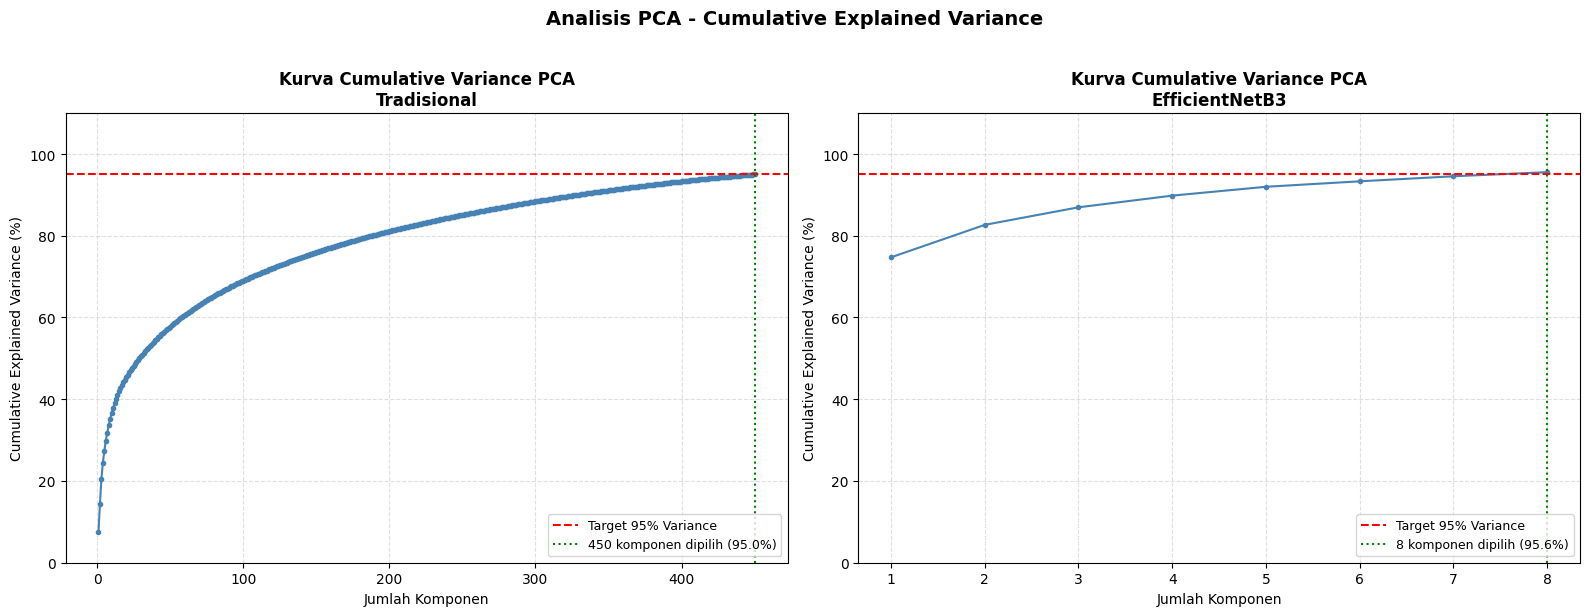

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (pca_model, label) in enumerate([(pca_trad, 'Tradisional'), (pca_deep, 'EfficientNetB3')]):
    ax         = axes[idx]
    cum_var    = np.cumsum(pca_model.explained_variance_ratio_) * 100
    x_ticks    = np.arange(1, len(cum_var) + 1)

    ax.plot(x_ticks, cum_var, 'o-', markersize=3, linewidth=1.5, color='steelblue')
    ax.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='Target 95% Variance')
    ax.axvline(x=len(cum_var), color='green', linestyle=':', linewidth=1.5,
               label=f'{len(cum_var)} komponen dipilih ({cum_var[-1]:.1f}%)')

    ax.set_title(f'Kurva Cumulative Variance PCA\n{label}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Jumlah Komponen')
    ax.set_ylabel('Cumulative Explained Variance (%)')
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Analisis PCA - Cumulative Explained Variance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

training model

In [ ]:
def evaluasi_otomatis(nama_skenario, y_true, y_pred, classes):
    print("\n" + "="*60)
    print(f" OUTPUT EVALUASI OTOMATIS: {nama_skenario}")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=classes))

    # Confussion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=classes, cmap='Blues', ax=ax, xticks_rotation=45)
    ax.set_title(f"Confusion Matrix\n{nama_skenario}", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

tradisional

tanpa rd


 OUTPUT EVALUASI OTOMATIS: Tradisional - Tanpa DR
              precision    recall  f1-score   support

        Mild       0.78      0.50      0.61       225
    Moderate       0.97      0.99      0.98       225
         Non       0.75      0.38      0.51       225
    VeryMild       0.44      0.81      0.57       225

    accuracy                           0.67       900
   macro avg       0.74      0.67      0.67       900
weighted avg       0.74      0.67      0.67       900



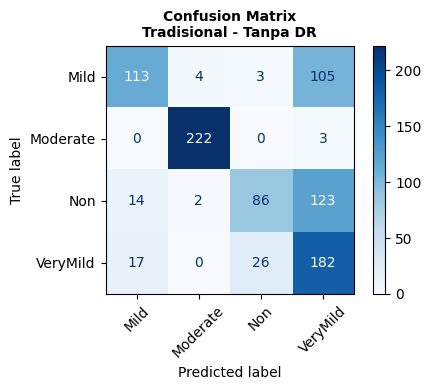

In [ ]:
svm_model.fit(X_train_trad_scaled, y_train_balanced) # Training menggunakan fitur skala penuh
y_pred_1 = svm_model.predict(X_test_trad_scaled)

evaluasi_otomatis("Tradisional - Tanpa DR", y_test, y_pred_1, class_names)

pca


 OUTPUT EVALUASI OTOMATIS: Tradisional - PCA
              precision    recall  f1-score   support

        Mild       0.76      0.53      0.62       225
    Moderate       0.97      0.99      0.98       225
         Non       0.76      0.38      0.51       225
    VeryMild       0.45      0.80      0.57       225

    accuracy                           0.67       900
   macro avg       0.73      0.67      0.67       900
weighted avg       0.73      0.67      0.67       900



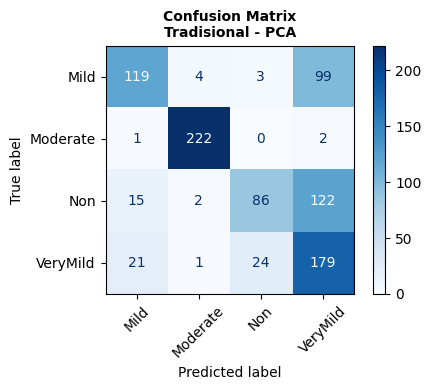

In [ ]:
svm_model.fit(X_train_trad_pca, y_train_balanced) # Training menggunakan fitur hasil PCA
y_pred_2 = svm_model.predict(X_test_trad_pca)

evaluasi_otomatis("Tradisional - PCA", y_test, y_pred_2, class_names)

umap


 OUTPUT EVALUASI OTOMATIS: Tradisional - UMAP
              precision    recall  f1-score   support

        Mild       0.34      0.14      0.20       225
    Moderate       0.30      0.75      0.43       225
         Non       0.39      0.25      0.31       225
    VeryMild       0.27      0.13      0.17       225

    accuracy                           0.32       900
   macro avg       0.33      0.32      0.28       900
weighted avg       0.33      0.32      0.28       900



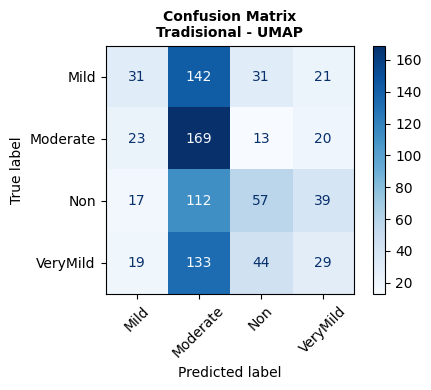

In [ ]:
svm_model.fit(X_train_trad_umap, y_train_balanced) # Training menggunakan fitur hasil UMAP
y_pred_3 = svm_model.predict(X_test_trad_umap)

evaluasi_otomatis("Tradisional - UMAP", y_test, y_pred_3, class_names)

efficientnetb3

tanpa rd


 OUTPUT EVALUASI OTOMATIS: EfficientNetB3 - Tanpa DR
              precision    recall  f1-score   support

        Mild       0.62      0.62      0.62       225
    Moderate       0.84      0.98      0.90       225
         Non       0.67      0.49      0.57       225
    VeryMild       0.45      0.50      0.47       225

    accuracy                           0.65       900
   macro avg       0.64      0.65      0.64       900
weighted avg       0.64      0.65      0.64       900



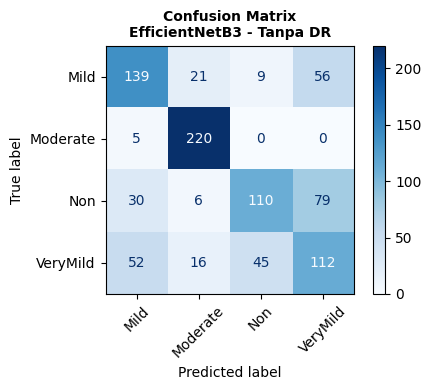

In [ ]:
svm_model.fit(X_train_deep_scaled, y_train_balanced) # Training menggunakan fitur skala penuh
y_pred_4 = svm_model.predict(X_test_deep_scaled)

evaluasi_otomatis("EfficientNetB3 - Tanpa DR", y_test, y_pred_4, class_names)

pca


 OUTPUT EVALUASI OTOMATIS: EfficientNetB3 - PCA
              precision    recall  f1-score   support

        Mild       0.36      0.17      0.23       225
    Moderate       0.42      0.67      0.52       225
         Non       0.45      0.51      0.48       225
    VeryMild       0.29      0.24      0.26       225

    accuracy                           0.40       900
   macro avg       0.38      0.40      0.37       900
weighted avg       0.38      0.40      0.37       900



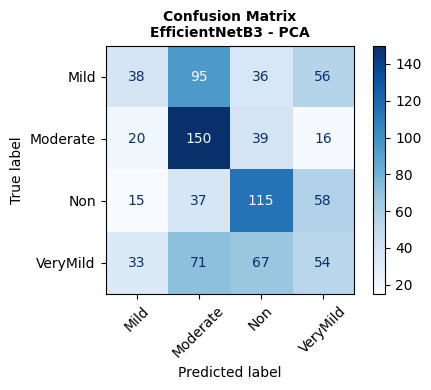

In [ ]:
svm_model.fit(X_train_deep_pca, y_train_balanced)
y_pred_5 = svm_model.predict(X_test_deep_pca)

evaluasi_otomatis("EfficientNetB3 - PCA", y_test, y_pred_5, class_names)

umap


 OUTPUT EVALUASI OTOMATIS: EfficientNetB3 - UMAP
              precision    recall  f1-score   support

        Mild       0.25      0.19      0.21       225
    Moderate       0.33      0.70      0.45       225
         Non       0.53      0.34      0.42       225
    VeryMild       0.30      0.16      0.21       225

    accuracy                           0.35       900
   macro avg       0.35      0.35      0.32       900
weighted avg       0.35      0.35      0.32       900



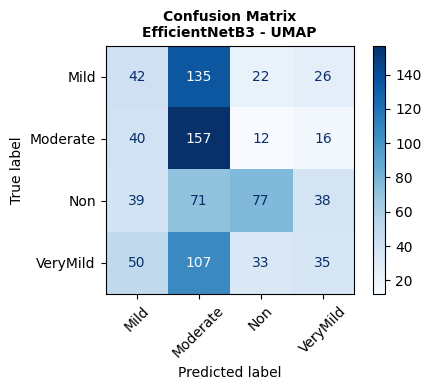

In [ ]:
svm_model.fit(X_train_deep_umap, y_train_balanced) # Training menggunakan fitur hasil UMAP
y_pred_6 = svm_model.predict(X_test_deep_umap)

evaluasi_otomatis("EfficientNetB3 - UMAP", y_test, y_pred_6, class_names)

In [ ]:
def hitung_metrik_model(nama_model, y_true, y_pred):
    """
    Fungsi untuk menghitung rata-rata nilai evaluasi
    dan mengembalikannya dalam bentuk dictionary.
    """
    acc = accuracy_score(y_true, y_pred) * 100

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    return {
        'Model/Skenario': nama_model,
        'Accuracy (%)': round(acc, 2),
        'Precision (%)': round(precision * 100, 2),
        'Recall (%)': round(recall * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2)
    }

In [ ]:
rekap_evaluasi = []

# JALUR TRADISIONAL
rekap_evaluasi.append(hitung_metrik_model("Tradisional - Tanpa DR", y_test, y_pred_1))
rekap_evaluasi.append(hitung_metrik_model("Tradisional - PCA", y_test, y_pred_2))
rekap_evaluasi.append(hitung_metrik_model("Tradisional - UMAP", y_test, y_pred_3))


# JALUR DEEP LEARNING (EfficientNetB3)

rekap_evaluasi.append(hitung_metrik_model("EfficientNetB3 - Tanpa DR", y_test, y_pred_4))
rekap_evaluasi.append(hitung_metrik_model("EfficientNetB3 - PCA", y_test, y_pred_5))
rekap_evaluasi.append(hitung_metrik_model("EfficientNetB3 - UMAP", y_test, y_pred_6))

df_rekap_model = pd.DataFrame(rekap_evaluasi)

print("\n================ TABEL REKAPITULASI EVALUASI MODEL ================")
display(df_rekap_model)


================ TABEL REKAPITULASI EVALUASI MODEL ================


,Model/Skenario,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Tradisional - Tanpa DR,67.00,73.67,67.00,66.73
1,Tradisional - PCA,67.33,73.46,67.33,67.06
2,Tradisional - UMAP,31.78,32.69,31.78,27.78
3,EfficientNetB3 - Tanpa DR,64.56,64.39,64.56,63.95
4,EfficientNetB3 - PCA,39.67,38.11,39.67,37.25
5,EfficientNetB3 - UMAP,34.56,35.47,34.56,32.18
